In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
# Definir la ruta del dataset
ruta = "./csv/student-mat.csv"

# Cargar el dataset
df = pd.read_csv(ruta)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [56]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [57]:
# 1. Creamos la columna 'aprobado' (1 si la nota final G3 es >= 10, 0 si no)
df['aprobado'] = (df['G3'] >= 10).astype(int)

# 2. Eliminamos las notas G1 y G2 para que el modelo no "haga trampa" 
# (si sabe las notas anteriores, predecir la final es demasiado fácil)
df_modelo = df.drop(['G1', 'G2', 'G3'], axis=1)

print(f"Dataset preparado. Total de alumnos: {len(df_modelo)}")
print(f"Alumnos aprobados: {df['aprobado'].sum()} | Suspensos: {len(df) - df['aprobado'].sum()}")

Dataset preparado. Total de alumnos: 395
Alumnos aprobados: 265 | Suspensos: 130


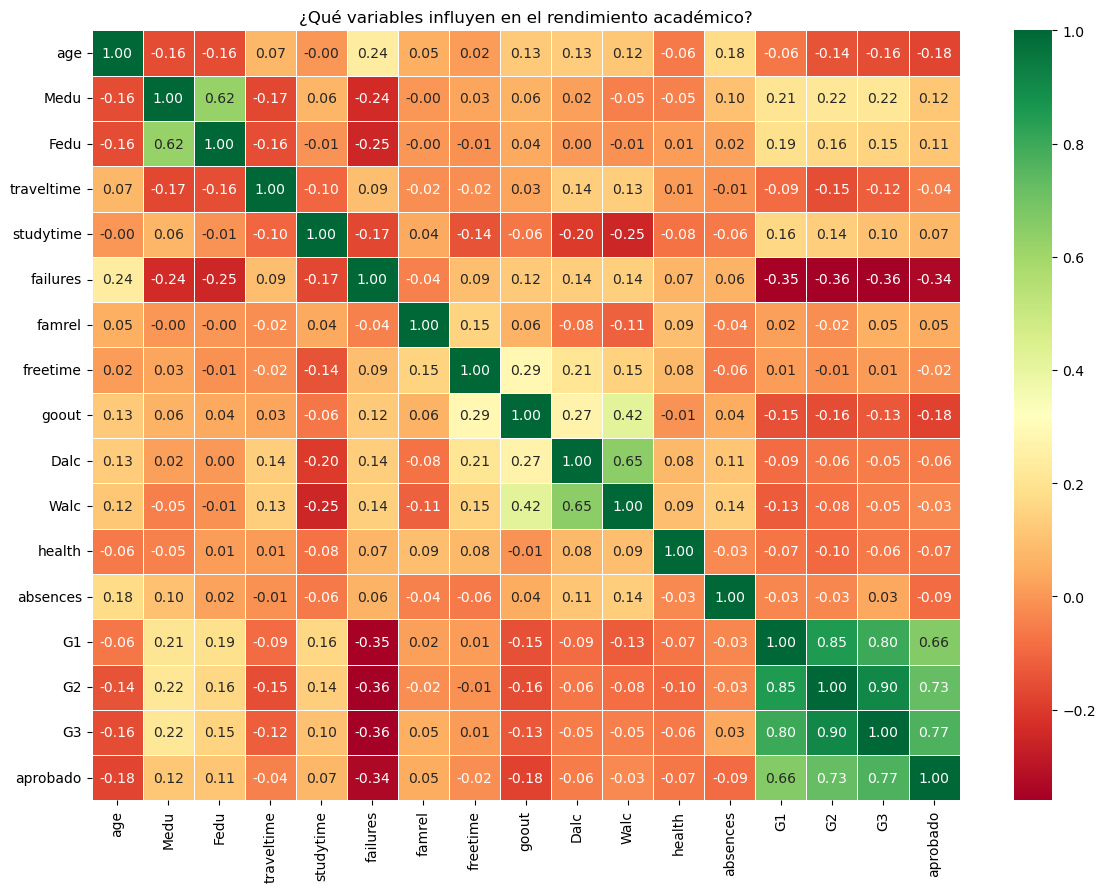

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos solo las columnas numéricas para el análisis de correlación
df_num = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14, 10))
sns.heatmap(df_num.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title("¿Qué variables influyen en el rendimiento académico?")
plt.show()

In [59]:

# 1. Preparar los datos (X son las preguntas, y es la respuesta)
# Primero creamos la columna 'aprobado' si no la tenías
df['aprobado'] = (df['G3'] >= 10).astype(int)

# Quitamos las notas para que el modelo no haga trampas
X = df.drop(['G1', 'G2', 'G3', 'aprobado'], axis=1)
y = df['aprobado']

# Convertimos los textos (como 'Urbano/Rural') a números automáticamente
X = pd.get_dummies(X, drop_first=True)

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


pipeline_academico = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
)

# 4. ¡Entrenar el cerebro!
pipeline_academico.fit(X_train, y_train)




print("✅ ¡IA Entrenada! Ahora el modelo ya sabe predecir quién aprobará.")

✅ ¡IA Entrenada! Ahora el modelo ya sabe predecir quién aprobará.


In [60]:
modelos = [
    ("modelo lineal", LinearRegression()),
    ("modelo arbol", RandomForestRegressor(random_state=42)),
    ("modelo bosque", RandomForestClassifier(random_state=42, class_weight='balanced'))
]

# Entrenar modelos y mostrar puntajes
for nombre, modelo in modelos:
    modelo.fit(X_train, y_train)
    puntaje = modelo.score(X_test, y_test)
    print(f'{nombre}: {puntaje}')

modelo lineal: 0.03390970218699263
modelo arbol: 0.14344081196581193
modelo bosque: 0.7088607594936709


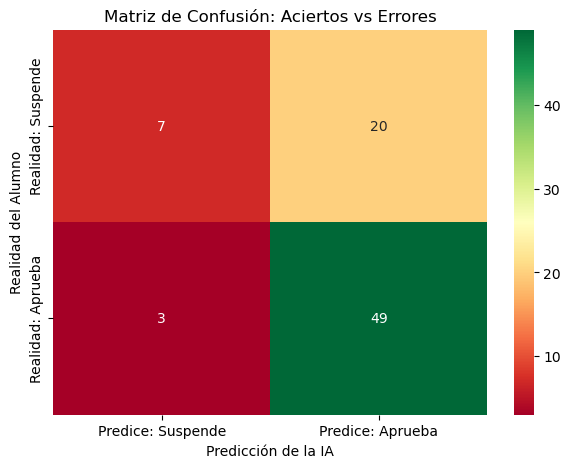

--- MÉTRICAS DETALLADAS ---
              precision    recall  f1-score   support

           0       0.70      0.26      0.38        27
           1       0.71      0.94      0.81        52

    accuracy                           0.71        79
   macro avg       0.71      0.60      0.59        79
weighted avg       0.71      0.71      0.66        79



In [61]:


# 1. El modelo intenta predecir el grupo de examen (X_test)
y_pred = pipeline_academico.predict(X_test)

# 2. Creamos la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 3. Dibujamos la matriz para entenderla visualmente
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Predice: Suspende', 'Predice: Aprueba'],
            yticklabels=['Realidad: Suspende', 'Realidad: Aprueba'])
plt.title('Matriz de Confusión: Aciertos vs Errores')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad del Alumno')
plt.show()

# 4. El reporte con los porcentajes de éxito
print("--- MÉTRICAS DETALLADAS ---")
print(classification_report(y_test, y_pred))

In [62]:
import joblib

# Creamos un diccionario con el modelo y los nombres de las columnas
# Es vital guardar las columnas para que la App sepa en qué orden preguntar
export_data = {
    'modelo': pipeline_academico,
    'columnas': X_train.columns.tolist()
}

joblib.dump(export_data, './modelo/modelo_predictor_estudiantes.pkl')
print("✅ Archivo 'modelo_predictor_estudiantes.pkl' creado con éxito.")

✅ Archivo 'modelo_predictor_estudiantes.pkl' creado con éxito.


Reflexión sobre el Modelo y Dilemas Técnicos
Durante el desarrollo de este modelo de clasificación, se plantearon varios dilemas técnicos clave que definieron la arquitectura final:

El dilema del "Score" (0.71 vs 0.96): Se observó una diferencia notable entre la varianza explicada en el proyecto de Steam (PCA ~0.96) y la exactitud de este modelo (~0.71). Tras el análisis, se determinó que en el aprendizaje supervisado, un puntaje cercano al 100% en datos humanos suele ser indicativo de Overfitting (sobreajuste o memorización), mientras que en el aprendizaje no supervisado (PCA), buscamos retener la mayor cantidad de información posible. El 71% actual representa un equilibrio saludable entre aprendizaje y capacidad de generalización para datos nuevos.

Dilema del Escalado: StandardScaler vs. MinMaxScaler: Se evaluó el uso de ambos escaladores. Se optó por StandardScaler debido a la naturaleza de las variables socioeconómicas y académicas, que presentan valores atípicos (outliers) como picos en faltas de asistencia o tiempo de estudio. StandardScaler es más robusto ante estos valores, permitiendo que el modelo no se sesgue por casos extremos.

Balanceo de Clases y Utilidad Social: Inicialmente, el modelo era "optimista", fallando en la detección de alumnos en riesgo de suspenso (Recall de ~0.19). Al implementar class_weight='balanced', sacrificamos una pequeña parte de la precisión global para priorizar la detección de casos críticos, mejorando la capacidad del modelo para identificar alumnos que realmente necesitan intervención pedagógica.